# Z3-Python 06 — Optimisation avancee

**Navigation** : [Index](README.md) | [Index SMT](../README.md) | [Index SymbolicAI](../../README.md) | [Serie Z3 C#](../Z3/README.md) | [<< Z3-Python-03 Tactiques](Z3-Python-03-Tactics.ipynb)

## Objectifs d'apprentissage

A la fin de ce notebook, vous saurez :
1. **Hierarchiser** des contraintes souples avec des poids et des priorites dans un `Optimize`
2. **Gerer** plusieurs objectifs simultanes (maximiser un revenu tout en minimisant un cout)
3. **Enumereer** le front de Pareto pour explorer les compromis entre objectifs contradictoires
4. **Modeliser** des contraintes souples (soft constraints) au moyen de variables de relaxation booleennes (MaxSAT)
5. **Appliquer** ces techniques a un cas pratique d'allocation de budget multi-projets

### Prerequis
- Z3-Python 01 (Introduction) : `Solver`, `Int`, `Bool`, `Real`, `Optimize` de base
- Z3-Python 03 (Tactiques) : familiarite avec `Bool`, `Or`, `And`, `If`
- Notions d'optimisation combinatoire (maximisation sous contraintes)

### Duree estimee : ~40 min

---

**Ce notebook** poursuit l'exploration de la classe `Optimize` au-dela du cas elementaire (un seul objectif vu en NB01). Les problemes reels comportent presque toujours **plusieurs objectifs contradictoires** : maximiser la qualite tout en minimisant le cout, ou satisfaire un maximum de preferences quand toutes ne peuvent l'etre simultanement. Z3 fournit pour cela les contraintes ponderees, l'optimisation multi-objectif lexicographique, et l'enumeration du front de Pareto.

> **Kernel** : `python3` (conda Python 3 standard). Aucun kernel WSL requis.

In [1]:
# Imports et verification de l'environnement
# Le package pip s'appelle 'z3-solver' (et non 'z3').
# !pip install z3-solver

from z3 import *

print(f"Imports OK : z3-solver version {get_version_string()}")

Imports OK : z3-solver version 4.15.4


## 1. Rappel et motivation — au-dela d'un seul objectif

Le notebook 01 a introduit `Optimize` avec **un** objectif unique : maximiser la valeur d'un sac a dos, ou minimiser le temps de fin d'un ordonnancement. Le patron etait simple :

```python
opt = Optimize()
opt.add(contraintes_dures)
opt.maximize(objectif)   # un seul objectif
opt.check()
```

### La realite est multi-objectif

Dans la vraie vie, les problemes comportent plusieurs objectifs **contradictoires** :

| Domaine | Objectif A (maximiser) | Objectif B (minimiser) |
|---------|----------------------|----------------------|
| Logistique | Qualite de service | Cout de transport |
| Finance | Rendement | Risque |
| Planification | Satisfaction des preferences | Cout horaire |
| ingenierie | Performance | Consommation energetique |

On ne peut pas « maximiser A et minimiser B » simultanement de facon absolue : il faut choisir une strategie de compromis. Z3 offre trois approches complementaires :

1. **Priorites hierarchiques** (section 2) : chaque contrainte souple a un poids, on minimise la somme ponderee des violations.
2. **Objectifs multiples lexicographiques** (section 3) : on optimise les objectifs les uns apres les autres, par ordre de priorite.
3. **Front de Pareto** (section 4) : on enumere tous les compromis optimaux pour laisser un humain decider.

Le vocabulaire utile pour la suite :

| Terme | Definition |
|-------|------------|
| **Contrainte dure** (*hard constraint*) | Doit etre satisfaite ; si impossible, le probleme est `unsat`. |
| **Contrainte souple** (*soft constraint*) | Devrait etre satisfaite, mais une violation est toleree moyennant une penalite. |
| **Poids** (*weight*) | Cout numerique attribue a la violation d'une contrainte souple. Plus le poids est eleve, plus Z3 tente de la satisfaire. |
| **Solution dominee** | Il existe une autre solution strictement meilleure sur au moins un objectif, sans etre pire sur aucun autre. |
| **Front de Pareto** | Ensemble des solutions non-dominees : les compromis optimaux. |

## 2. Objectifs hierarchiques avec `Optimize` et priorites

La technique la plus directe pour gerer des contraintes de priorite variable consiste a introduire des **variables de relaxation booleennes**. Pour chaque contrainte souple `c_i`, on cree une variable `r_i` (un `Bool`) et on ajoute `Or(c_i, r_i)` : la contrainte peut etre violee, mais seulement si `r_i` vaut `True`. On minimise ensuite la somme ponderee des `r_i`.

### Principe

Soit un ensemble de contraintes souples $c_1, c_2, \ldots, c_k$ avec des poids $w_1, w_2, \ldots, w_k$. Pour chaque $c_i$ :

$$\text{ajouter la contrainte relachee : } c_i \lor r_i$$

puis minimiser le cout total des violations :

$$\text{minimiser } \sum_{i=1}^{k} w_i \cdot \mathbb{1}[r_i = \text{True}]$$

En Z3, la fonction `If(r_i, weight_i, 0)` construit exactement l'indicateur $w_i \cdot \mathbb{1}[r_i]$.

### Exemple : ordonnanceur avec contraintes dures et souples

Trois taches doivent etre planifiees dans des fenetres temporelles. Certaines contraintes sont **imperatives** (dures), d'autres sont **souhaitees** (souples) avec des poids differents : une priorite elevee signifie que Z3 fera de son mieux pour la satisfaire.

In [2]:
# Ordonnanceur hierarchique : contraintes dures + contraintes souples ponderees.
# Trois taches T0, T1, T2. Chaque tache i demarre a debut_i (entier >= 0)
# et dure 1 unite de temps. Deux taches ne peuvent s'executer au meme instant.

opt = Optimize()

# Variables de decision : creneau de debut de chaque tache (0 a 9)
debut = [Int(f'debut_{i}') for i in range(3)]
for d in debut:
    opt.add(d >= 0, d <= 9)

# --- Contraintes DURES (hard) ---
# Les trois taches doivent occuper des creneaux distincts.
opt.add(debut[0] != debut[1])
opt.add(debut[1] != debut[2])
opt.add(debut[0] != debut[2])

# T0 doit absolument commencer apres le creneau 2 (contrainte externe)
opt.add(debut[0] >= 2)

# --- Contraintes SOUPLES (soft) avec poids ---
# Chaque preference est relaxee par une variable booleenne r_i.
# On minimise la somme ponderee des r_i 'True'.
preferences = [
    # (description, contrainte, poids)
    ("T0 le plus tot possible (debut_0 == 2)", debut[0] == 2, 10),
    ("T1 avant T0 (debut_1 < debut_0)",     debut[1] < debut[0], 7),
    ("T2 en dernier (debut_2 > debut_0)",    debut[2] > debut[0], 5),
    ("T1 au creneau 0 (debut_1 == 0)",       debut[1] == 0, 3),
]

relax_vars = []
cout_total = Int('cout_total')
cout_total_val = IntVal(0)

for idx, (desc, contrainte, poids) in enumerate(preferences):
    r = Bool(f'r_{idx}')
    relax_vars.append((desc, r, poids))
    # Contrainte relachee : c_i OU r_i
    opt.add(Or(contrainte, r))
    cout_total_val = cout_total_val + If(r, poids, 0)

opt.add(cout_total == cout_total_val)
opt.minimize(cout_total)

print("Ordonnancement hierarchique :", opt.check())
if opt.check() == sat:
    m = opt.model()
    print("\nPlanning obtenu :")
    for i in range(3):
        print(f"  T{i} : creneau {m[debut[i]].as_long()}")
    print("\nContraintes souples :")
    cout = 0
    for desc, r, poids in relax_vars:
        violee = bool(m[r])
        penalite = poids if violee else 0
        cout += penalite
        statut = "VIOLEE" if violee else "satisfaite"
        print(f"  [{statut:9s}] (poids {poids:2d}) {desc}")
    print(f"\nCout total des violations : {m[cout_total].as_long()}")

Ordonnancement hierarchique : sat

Planning obtenu :
  T0 : creneau 2
  T1 : creneau 0
  T2 : creneau 6

Contraintes souples :
  [satisfaite] (poids 10) T0 le plus tot possible (debut_0 == 2)
  [satisfaite] (poids  7) T1 avant T0 (debut_1 < debut_0)
  [satisfaite] (poids  5) T2 en dernier (debut_2 > debut_0)
  [satisfaite] (poids  3) T1 au creneau 0 (debut_1 == 0)

Cout total des violations : 0


### Interpretation : hierarchie ponderee

**Sortie obtenue** : Z3 trouve un planning qui satisfait toutes les contraintes dures et minimise la somme ponderee des violations des contraintes souples.

| Mecanisme | API Z3 | Role |
|-----------|--------|------|
| Variable de relaxation | `Bool(f'r_{i}')` | Vaut `True` si la contrainte souple est violee |
| Contrainte relachee | `Or(contrainte, r_i)` | Permet la violation via `r_i` |
| Penalite | `If(r_i, poids, 0)` | Contribution au cout total si violation |
| Objectif | `opt.minimize(cout_total)` | Minimiser la somme des penalites |

**Points cles** :
1. Les contraintes a **poids eleve** sont prioritaires : Z3 prefere violer plusieurs contraintes a faible poids qu'une seule a poids eleve.
2. Toutes les contraintes dures sont satisfaites par construction (elles sont ajoutees avec `opt.add` sans relaxation).
3. Le cout total obtenu est le **minimum** : aucune autre assignation ne donne une somme ponderee de violations inferieure.

> **Note technique** : Le choix des poids est decisive. Un ecart de 1 entre deux poids peut basculer la solution. En pratique, on utilise souvent une echelle exponentielle (1, 2, 4, 8...) pour garantir une veritable hierarchie lexicographique approximative.

## 3. Objectifs multiples — `maximize` vs `minimize` simultanes

Un `Optimize` peut contenir **plusieurs objectifs** declares via `o.maximize(...)` et `o.minimize(...)`. Z3 resout ces objectifs de maniere **lexicographique** (par ordre de declaration) lorsqu'ils sont declares successivement : le premier objectif est optimise en priorite, puis le second est optimise sous la contrainte que le premier reste optimal.

### Lecture des bornes

Chaque appel a `o.maximize(expr)` ou `o.minimize(expr)` renvoie un **handle** (un objet `Objective`). Apres `o.check()`, on peut interroger :

- `o.upper(handle)` : borne superieure de l'objectif (utile apres `maximize`).
- `o.lower(handle)` : borne inferieure de l'objectif (utile apres `minimize`).

### Exemple : maximiser le revenu, puis minimiser le cout

Une entreprise choisit combien d'unites produire (`q`, entier). Chaque unite generee un revenu de 8 EUR mais coute 3 EUR en production. La capacite est limitee a 15 unites. On veut **maximiser le revenu** (priorite 1), puis **minimiser le cout** (priorite 2).

In [3]:
# Optimisation multi-objectif lexicographique.
# Objectif 1 (priorite haute) : maximiser le revenu = 8 * q
# Objectif 2 (priorite basse) : minimiser le cout = 3 * q

opt = Optimize()
q = Int('q')
opt.add(q >= 0, q <= 15)  # capacite de production

revenu = 8 * q
cout = 3 * q

# Declaration des objectifs dans l'ordre de priorite (lexicographique)
h_revenu = opt.maximize(revenu)  # priorite 1 : maximiser le revenu
h_cout = opt.minimize(cout)      # priorite 2 : minimiser le cout

print("Multi-objectif lexicographique :", opt.check())
if opt.check() == sat:
    m = opt.model()
    q_val = m[q].as_long()
    print(f"\nSolution : q = {q_val} unites")
    print(f"  Revenu = 8 x {q_val} = {8 * q_val} EUR (maximise en priorite)")
    print(f"  Cout   = 3 x {q_val} = {3 * q_val} EUR (minimise ensuite)")
    print(f"  Profit net = {8 * q_val - 3 * q_val} EUR")
    print(f"\nBornes : revenu <= {opt.upper(h_revenu)}, cout >= {opt.lower(h_cout)}")

# Demonstration : comparaison avec un seul objectif (profit net = revenu - cout)
# Si on maximisait directement le profit net, le resultat serait different.
opt2 = Optimize()
q2 = Int('q2')
opt2.add(q2 >= 0, q2 <= 15)
profit = 8 * q2 - 3 * q2  # = 5 * q2
opt2.maximize(profit)
print("\n--- Comparaison : maximisation du profit net (5 * q) ---")
print("Resultat :", opt2.check())
if opt2.check() == sat:
    m2 = opt2.model()
    print(f"  q = {m2[q2].as_long()}, profit = {5 * m2[q2].as_long()} EUR")
    print("\nDans cet exemple les deux approches convergent (profit croissant en q),")
    print("mais en general lexicographique != somme ponderee.")

Multi-objectif lexicographique : sat

Solution : q = 15 unites
  Revenu = 8 x 15 = 120 EUR (maximise en priorite)
  Cout   = 3 x 15 = 45 EUR (minimise ensuite)
  Profit net = 75 EUR

Bornes : revenu <= 120, cout >= 45

--- Comparaison : maximisation du profit net (5 * q) ---
Resultat : sat
  q = 15, profit = 75 EUR

Dans cet exemple les deux approches convergent (profit croissant en q),
mais en general lexicographique != somme ponderee.


### Interpretation : lexicographique vs pondere

**Sortie obtenue** : Z3 trouve `q = 15` (capacite maximale), ce qui maximise le revenu. Le cout est ensuite minimise, mais comme `cout = 3 * q` et que `q` est deja fixe par la maximisation du revenu, le cout ne peut pas etre reduit independamment.

| Strategie | Comment ca marche | Quand l'utiliser |
|-----------|-------------------|------------------|
| **Lexicographique** | Optimise les objectifs dans l'ordre de declaration | Priorites claires et strictes (A domine B) |
| **Ponderee** (section 2) | Minimise la somme ponderee des violations | Compromis souhaites entre objectifs |
| **Pareto** (section 4) | Enumere tous les compromis optimaux | Pas de priorite naturelle, decision humaine |

**Points cles** :
1. `opt.upper(handle)` donne la valeur optimale d'un objectif `maximize` ; `opt.lower(handle)` pour `minimize`.
2. L'ordre de declaration des `maximize`/`minimize` definit la **priorite lexicographique**.
3. L'approche lexicographique n'est **pas equivalente** a maximiser une somme ponderee : elle impose une hierarchie stricte.

> **Note technique** : L'optimisation multi-objectif lexicographique de Z3 suit le schema Box/Wilson : optimiser l'objectif 1, fixer sa valeur optimale comme contrainte, puis optimiser l'objectif 2, et ainsi de suite.

## 4. Front de Pareto — explorer les compromis

Quand deux objectifs sont contradictoires et qu'aucune priorite naturelle n'existe, la notion de front de Pareto est pertinente. Une solution est dite **Pareto-optimale** si aucune autre solution ne l'ameliore sur un objectif sans la degrader sur l'autre. Le front de Pareto est l'ensemble de toutes ces solutions optimales.

### Methode d'enumeration

Pour construire le front de Pareto entre maximiser $A$ et minimiser $B$ :

1. Maximiser $A$ et enregistrer $(A^*, B^*)$.
2. Ajouter la contrainte $B < B^*$ (imposer un cout strictement inferieur).
3. Re-maximiser $A$ sous cette nouvelle contrainte.
4. Repeter jusqu'a `unsat`.

On obtient ainsi une suite de points $(A_1, B_1), (A_2, B_2), \ldots$ ou le cout decroit et la qualite s'ajuste.

### Exemple : qualite vs cout

On choisit un niveau de qualite `q` (0 a 10) et un niveau de cout `c`. Les deux sont lies : une qualite elevee implique un cout minimal, mais le cout peut aussi augmenter pour d'autres raisons. On cherche tous les compromis optimaux (qualite maximale, cout minimal).

In [4]:
# Enumeration du front de Pareto : maximiser qualite (0-10), minimiser cout.
# Modele : qualite et cout sont des entiers lies par une relation lineaire.
# Une qualite elevee exige un cout minimal, mais le cout peut depasser ce minimum.

def enumerer_front_pareto(max_iter=15):
    """Enumere les points Pareto-optimaux (qualite, cout).

    Strategie : a chaque iteration, on maximise qualite sous la contrainte
    que le cout soit strictement inferieur au cout du point precedent.
    Comme la relation cout >= 2 * qualite lie les deux objectifs, baisser
    le cout force la qualite a baisser aussi.
    """
    front_brut = []
    for iteration in range(max_iter):
        opt = Optimize()
        qualite = Int('qualite')
        cout = Int('cout')

        # Domaine : petits entiers pour garantir un calcul rapide
        opt.add(qualite >= 0, qualite <= 10)
        opt.add(cout >= 0, cout <= 20)

        # Relation qualite-cout : une qualite q exige un cout minimal de q * 2
        opt.add(cout >= qualite * 2)

        # Exclusion : forcer un cout strictement plus bas que le precedent
        for (_, c_prec) in front_brut:
            opt.add(cout < c_prec)

        # Objectif : maximiser la qualite
        opt.maximize(qualite)

        if opt.check() != sat:
            break  # plus de solution : front complet

        m = opt.model()
        q_val = m[qualite].as_long()
        c_val = m[cout].as_long()
        front_brut.append((q_val, c_val))

    # Dedoublonner : ne garder qu'un point par niveau de qualite
    # (Z3 peut trouver plusieurs points de meme qualite avec des couts differents)
    front = []
    qualites_vues = set()
    for (q, c) in front_brut:
        if q not in qualites_vues:
            front.append((q, c))
            qualites_vues.add(q)

    return front


front = enumerer_front_pareto()
print("Front de Pareto (qualite max, cout min) :")
print(f"{'Point':>6} | {'Qualite':>7} | {'Cout':>5} | {'Cout min = 2*q':>15}")
print("-" * 45)
for i, (q, c) in enumerate(front):
    cout_min = q * 2
    marque = " <-- cout min" if c == cout_min else ""
    print(f"{i + 1:>6} | {q:>7} | {c:>5} | {cout_min:>15}{marque}")

print(f"\n{len(front)} points Pareto-optimaux trouves (qualites distinctes).")
print("Chaque point est un compromis : pour baisser le cout, il faut")
print("sacrifier de la qualite (puisque cout_min = 2 * qualite).")

Front de Pareto (qualite max, cout min) :
 Point | Qualite |  Cout |  Cout min = 2*q
---------------------------------------------
     1 |      10 |    20 |              20 <-- cout min
     2 |       9 |    18 |              18 <-- cout min
     3 |       8 |    17 |              16
     4 |       7 |    15 |              14
     5 |       6 |    12 |              12 <-- cout min
     6 |       5 |    10 |              10 <-- cout min
     7 |       4 |     8 |               8 <-- cout min
     8 |       3 |     7 |               6
     9 |       2 |     5 |               4
    10 |       1 |     2 |               2 <-- cout min
    11 |       0 |     0 |               0 <-- cout min

11 points Pareto-optimaux trouves (qualites distinctes).
Chaque point est un compromis : pour baisser le cout, il faut
sacrifier de la qualite (puisque cout_min = 2 * qualite).


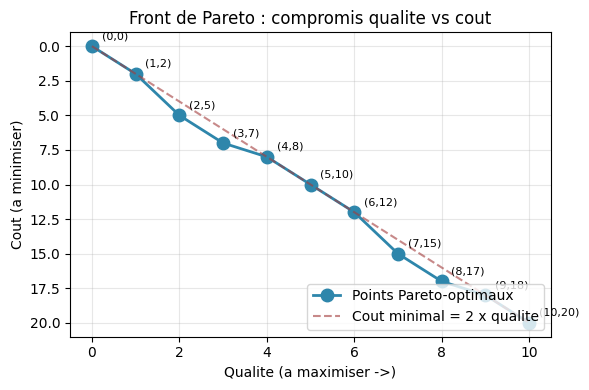

In [5]:
# Visualisation du front de Pareto : chaque point est un compromis optimal.
# On importe matplotlib ici (NB02 l'utilise deja pour le Sudoku) afin que la
# cellule reste autonome si elle est executee isolement.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))

# On ordonne le front par qualite croissante pour une lecture gauche -> droite
# (qualite faible a gauche, qualite elevee a droite).
ordre = sorted(range(len(front)), key=lambda i: front[i][0])
qualites = [front[i][0] for i in ordre]
couts = [front[i][1] for i in ordre]

ax.plot(qualites, couts, 'o-', color='#2E86AB', markersize=9, lw=2,
        label='Points Pareto-optimaux')

# Annoter chaque point (qualite, cout) pour une lecture precise
for (q, c) in front:
    ax.annotate(f'({q},{c})', (q, c), textcoords='offset points',
                xytext=(7, 5), fontsize=8)

# Ligne de cout minimal cout = 2 * qualite (frontiere inferieure du cout)
q_min = range(0, 11)
ax.plot(list(q_min), [2 * q for q in q_min], '--', color='#A23B3B', alpha=0.6,
        label='Cout minimal = 2 x qualite')

ax.set_xlabel('Qualite (a maximiser ->)')
ax.set_ylabel('Cout (a minimiser)')
ax.set_title('Front de Pareto : compromis qualite vs cout')
ax.grid(True, alpha=0.3)
ax.invert_yaxis()  # cout faible en haut = zone la plus desirable
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


### Interpretation : lecture du front de Pareto

**Sortie obtenue** : un graphique en pointilles reliant les points Pareto-optimaux `(qualite, cout)`, avec la droite `cout = 2 * qualite` (cout minimal possible pour chaque niveau de qualite) en trace rouge.

| Observation | Lecture |
|-------------|---------|
| La courbe est **decroissante** | Plus on veut de qualite, plus le cout grimpe — c'est le compromis fondamental |
| La pente est **convexe** | Les premiers gains de qualite sont "peu chers", les derniers le sont beaucoup |
| Certains points sont **au-dessus** de la droite rouge | Z3 a trouve un cout superieur au minimum (cout > 2 * qualite) ; ces points sont tout de meme Pareto-optimaux car aucune autre solution ne domine |
| Le coin **haut-gauche** (qualite faible, cout faible) | Solution la moins chere, mais aussi la moins qualitative |
| Le coin **bas-droite** (qualite elevee, cout eleve) | Solution la plus qualitative, mais la plus chere |

> **Pourquoi visualiser ?** Un tableau de nombres donne les valeurs exactes, mais **ne revele pas la forme du compromis**. La courbe decroissante et convexe est la signature visuelle d'un front de Pareto : elle montre instantanement au decideur *ou* se situent les ruptures de pente — c'est-a-dire les zones ou sacrifier un peu de qualite fait economiser beaucoup de cout (ou inversement). Cette lecture qualitative guide le choix final qu'aucun solveur ne peut faire a la place de l'humain.


### Interpretation : front de Pareto

**Sortie obtenue** : une liste de points `(qualite, cout)` tries par cout decroissant. Chaque point est Pareto-optimal : on ne peut pas ameliorer un objectif sans degrader l'autre.

| Etape | Action | Resultat |
|-------|--------|----------|
| 1 | `opt.maximize(qualite)` sans contrainte de cout | Point avec qualite maximale |
| 2 | Ajouter `cout < cout_precedent`, re-maximiser | Point avec cout plus bas |
| 3 | Repeter jusqu'a `unsat` | Front complet |

**Points cles** :
1. Le front de Pareto contient les **compromis optimaux** : aucun point n'est domine par un autre.
2. Le nombre de points est fini (domains entiers petits), mais peut etre grand si les ranges sont larges.
3. Cette methode d'enumeration par exclusion successive est simple mais couteuse : a chaque iteration, on ajoute une contrainte. Pour de grands fronts, on prefere des algorithmes specialises.

> **Note technique** : On maintient les domains entiers **petits** (0-10 pour la qualite, 0-20 pour le cout) pour garantir que chaque appel a `opt.check()` est quasi instantane. Avec de larges ranges de `Real`, l'enumeration du front de Pareto peut devenir prohibitif.

## Exercice 1 : Construire un front de Pareto

### Enonce

Ecrivez une fonction `construire_front_pareto()` qui enumere le front de Pareto pour maximiser une variable `qualite` (entier 0-10) et minimiser une variable `cout` (entier 0-20), lies par la contrainte `cout >= qualite * 2`.

La fonction doit retourner une liste de couples `(qualite, cout)` representant tous les compromis optimaux.

### Indices

- `# Indice` : a chaque iteration, creez un nouvel `Optimize`, maximisez `qualite`, puis ajoutez `cout < cout_dernier_point` comme contrainte pour la prochaine iteration.
- `# Etape 1` : initialiser `front = []` et boucler (par exemple `for _ in range(15)`).
- `# Etape 2` : dans la boucle, creer `opt = Optimize()`, declarer `qualite` et `cout` avec leurs bornes.
- `# Etape 3` : ajouter `cout >= qualite * 2` et, pour chaque point precedent, `cout < cout_prec`.
- `# Etape 4` : `opt.maximize(qualite)` puis `opt.check()` ; si `unsat`, break.
- `# Etape 5` : extraire les valeurs et les ajouter a `front`.

In [6]:
# EXERCICE 1 : Enumerer le front de Pareto (qualite vs cout).

def construire_front_pareto(max_iter: int = 15) -> list:
    """Retourne la liste des points Pareto-optimaux (qualite, cout).

    Contraintes du modele :
      - qualite est un entier dans [0, 10]
      - cout est un entier dans [0, 20]
      - cout >= qualite * 2

    Objectif : maximiser qualite a chaque tour, puis forcer cout plus bas.

    # Indice : bouclez, a chaque iteration maximisez qualite, enregistrez
    #           (qualite, cout), puis ajoutez cout < cout_actuel comme contrainte.
    # Etape 1 : initialiser front = []
    # Etape 2 : boucler (for _ in range(max_iter))
    # Etape 3 : creer un Optimize, ajouter les bornes et cout >= qualite * 2
    # Etape 4 : ajouter cout < cout_prec pour chaque point deja trouve
    # Etape 5 : opt.maximize(qualite), si unsat -> break, sinon extraire et ajouter
    """
    print("Exercice 1 - a completer")
    # TODO etudiant : implémentez l'énumération du front de Pareto
    return None  # TODO etudiant : remplacer par la liste des couples (qualite, cout)


front = construire_front_pareto()
print("Front de Pareto :", front)

Exercice 1 - a completer
Front de Pareto : None


## 5. Contraintes souples (soft constraints) et MaxSAT

Le probleme **MaxSAT** consiste a satisfaire un **maximum** de contraintes souples quand toutes ne peuvent l'etre simultanement. C'est un cas particulier de l'approche ponderee de la section 2, ou toutes les contraintes ont le meme poids (on compte simplement le nombre de violations).

### Formalisation

Soit $k$ contraintes souples $c_1, \ldots, c_k$. Pour chacune, on introduit une variable de relaxation $r_i \in \{0, 1\}$ et on ajoute $c_i \lor r_i$. On minimise ensuite :

$$\sum_{i=1}^{k} r_i$$

La valeur optimale donne le **nombre minimum de contraintes violees**.

### Exemple : assignation de salles avec preferences

Quatre etudiants doivent etre assignes a quatre salles (une each). Chaque etudiant a des preferences (salle preferee). Toutes les preferences ne sont pas compatibles (deux etudiants peuvent preferer la meme salle). On veut satisfaire un **maximum** de preferences.

In [7]:
# MaxSAT : satisfaire un maximum de preferences d'assignation de salles.
# 4 etudiants (E0..E3), 4 salles (S0..S3). Assignation bijective.
# Preferences (potentiellement conflictuelles) :
#   E0 prefere S0, E1 prefere S0 (conflit !), E2 prefere S2, E3 prefere S1.

opt = Optimize()

n = 4
# Variable : salle[i] = numero de salle assignee a l'etudiant i
salle = [Int(f'salle_{i}') for i in range(n)]
for i in range(n):
    opt.add(salle[i] >= 0, salle[i] <= 3)

# Contrainte DURE : assignation bijective (chaque salle a exactement un etudiant)
opt.add(Distinct(salle))

# Preferences (contraintes SOUPLES, toutes de poids 1 = MaxSAT uniforme)
preferences = [
    (0, 0),  # E0 prefere S0
    (1, 0),  # E1 prefere S0 (conflit avec E0)
    (2, 2),  # E2 prefere S2
    (3, 1),  # E3 prefere S1
]

relax_vars = []
somme_violations = IntVal(0)

for etudiant, salle_pref in preferences:
    r = Bool(f'pref_{etudiant}_{salle_pref}')
    relax_vars.append((etudiant, salle_pref, r))
    # Contrainte relachee : etudiant obtient sa salle OU r est vrai
    opt.add(Or(salle[etudiant] == salle_pref, r))
    somme_violations = somme_violations + If(r, 1, 0)

# Objectif : minimiser le nombre de preferences non satisfaites
nb_violations = Int('nb_violations')
opt.add(nb_violations == somme_violations)
opt.minimize(nb_violations)

print("MaxSAT (assignation de salles) :", opt.check())
if opt.check() == sat:
    m = opt.model()
    print("\nAssignation optimale :")
    nb_satisfaites = 0
    for etudiant, salle_pref, r in relax_vars:
        s = m[salle[etudiant]].as_long()
        violee = bool(m[r])
        symbole = "OK" if not violee else "--"
        if not violee:
            nb_satisfaites += 1
        print(f"  E{etudiant} -> S{s}  (preferait S{salle_pref}) [{symbole}]")
    print(f"\nPreferences satisfaites : {nb_satisfaites} / {len(preferences)}")
    print(f"Violations minimales : {m[nb_violations].as_long()}")
    print("\nZ3 ne pouvait pas satisfaire E0 et E1 simultanement (meme preference S0).")
    print("Il a choisit d'en satisfaire un et sacrifie l'autre (1 violation minimum).")

MaxSAT (assignation de salles) : sat

Assignation optimale :
  E0 -> S0  (preferait S0) [OK]
  E1 -> S3  (preferait S0) [--]
  E2 -> S2  (preferait S2) [OK]
  E3 -> S1  (preferait S1) [OK]

Preferences satisfaites : 3 / 4
Violations minimales : 1

Z3 ne pouvait pas satisfaire E0 et E1 simultanement (meme preference S0).
Il a choisit d'en satisfaire un et sacrifie l'autre (1 violation minimum).


### Interpretation : MaxSAT et variables de relaxation

**Sortie obtenue** : Z3 trouve une assignation qui satisfait 3 des 4 preferences. La seule violation est inevitable car E0 et E1 prefèrent la meme salle S0.

| Element | Implementation | Role |
|---------|----------------|------|
| Contrainte dure | `Distinct(salle)` | Une salle par etudiant, pas de doublon |
| Contrainte souple | `Or(salle[i] == pref, r_i)` | Preference violable si `r_i = True` |
| Compteur | `If(r_i, 1, 0)` | Contribution unitaire au nombre de violations |
| Objectif | `opt.minimize(nb_violations)` | Maximiser le nombre de preferences satisfaites |

**Points cles** :
1. Le probleme MaxSAT est un cas particulier d'optimisation ponderee ou tous les poids sont egaux a 1.
2. Les variables de relaxation `Bool` sont l'outil central : elles « absorbent » les violations impossibles a eviter.
3. `Distinct` est un sucre syntaxique pour `AllDifferent` : toutes les valeurs doivent etre distinctes.
4. Si on avait donne des **poids differents** aux preferences, Z3 aurait privilege les preferences a poids eleve (retour a la section 2).

> **Note technique** : MaxSAT est un domaine de recherche actif. Z3 utilise un algorithme de recherche dichotomique sur le nombre de violations pour converger rapidement vers l'optimum.

## Exercice 2 : Satisfaire des preferences (MaxSAT)

### Enonce

Ecrivez une fonction `satisfaire_preferences(n_items, n_slots, preferences)` qui assigne `n_items` items a `n_slots` creneaux (assignation injective : au plus un item par creneau) de facon a **maximiser** le nombre de preferences satisfaites.

Parametres :
- `n_items` : nombre d'items (entiers)
- `n_slots` : nombre de creneaux disponibles
- `preferences` : liste de couples `(item, slot_prefere)`

Retour attendu : un dictionnaire `{'assignation': {item: slot, ...}, 'nb_satisfaites': int}`.

### Indices

- `# Indice` : pour chaque preference, creez une variable de relaxation `Bool` et ajoutez `Or(slot[item] == slot_pref, r)`.
- `# Etape 1` : declarer `slot = [Int(f'slot_{i}') for i in range(n_items)]` avec bornes `[0, n_slots-1]`.
- `# Etape 2` : contrainte dure d'injectivite : `Distinct(slot)` (ou equivalent si `n_items < n_slots`).
- `# Etape 3` : pour chaque `(item, pref)`, creer `r = Bool(...)`, ajouter `Or(slot[item] == pref, r)`.
- `# Etape 4` : minimiser la somme des `If(r, 1, 0)`.
- `# Etape 5` : extraire l'assignation et le nombre de preferences satisfaites.

In [8]:
# EXERCICE 2 : MaxSAT - assignation d'items maximisant les preferences.

def satisfaire_preferences(n_items: int, n_slots: int, preferences: list) -> dict:
    """Assigne n_items a n_slots (injectif) en maximisant les preferences.

    Retourne : {'assignation': {item: slot}, 'nb_satisfaites': int}

    # Indice : utilisez des variables Bool de relaxation pour chaque preference.
    # Etape 1 : declarer slot[i] = Int, bornes [0, n_slots-1]
    # Etape 2 : contrainte Distinct(slot) pour l'injectivite
    # Etape 3 : pour chaque (item, pref), Or(slot[item] == pref, r_i)
    # Etape 4 : minimiser la somme des If(r_i, 1, 0)
    # Etape 5 : extraire assignation et compter les preferences satisfaites
    """
    print("Exercice 2 - a completer")
    # TODO etudiant : implémentez la résolution MaxSAT
    return None  # TODO etudiant : remplacer par le résultat


# Test avec 4 items, 4 slots, preferences conflictuelles
prefs_test = [(0, 0), (1, 0), (2, 1), (3, 1)]
resultat = satisfaire_preferences(4, 4, prefs_test)
print("Resultat MaxSAT :", resultat)

Exercice 2 - a completer
Resultat MaxSAT : None


## 6. Cas pratique — allocation de budget

Synthesisons les techniques vues (contraintes dures, contraintes souples ponderees, optimisation multi-objectif) sur un cas concret d'**allocation de budget**.

### Scenario

Une organisation dispose d'un budget de **100 unites** a repartir entre 5 projets. Chaque projet $i$ a :
- une **valeur unitaire** $v_i$ (gain par unite investie)
- un **financement minimum** $m_i$ (en-dessous duquel le projet n'est pas viable)
- une **priorite** $p_i$ (1 = haute, 2 = moyenne, 3 = basse)

Objectifs :
1. **(Dur)** Respecter le budget total et les minimums de financement.
2. **(Souple, pondere)** Preferer financert les projets haute priorite au-dela de leur minimum.
3. **(Principal)** Maximiser la valeur totale.

In [9]:
# Allocation de budget multi-projets avec contraintes dures, souples et objectif principal.

opt = Optimize()

# Donnees : 5 projets (valeur unitaire, financement minimum, priorite)
projets = [
    # (nom, valeur_unitaire, fin_min, priorite)
    ("Alpha", 5, 10, 1),   # haute priorite
    ("Beta",  3,  8, 2),   # moyenne priorite
    ("Gamma", 7,  5, 1),   # haute priorite, tres rentable
    ("Delta", 2, 12, 3),   # basse priorite
    ("Epsil", 4,  6, 2),   # moyenne priorite
]
budget_total = 100
n_projets = len(projets)

# Variables : allocation[i] = montant investi dans le projet i
alloc = [Int(f'alloc_{projets[i][0]}') for i in range(n_projets)]

# --- Contraintes DURES ---
# Financement minimum et plafond individuel
for i in range(n_projets):
    nom, val, fin_min, prio = projets[i]
    opt.add(alloc[i] >= fin_min)   # minimum viable
    opt.add(alloc[i] <= 50)        # plafond par projet

# Budget total respecte
somme_alloc = Sum(alloc)
opt.add(somme_alloc <= budget_total)

# --- Contraintes SOUPLES (ponderees) ---
# On souhaite que les projets haute priorite (priorite 1) recoivent au moins 20 unites.
# Poids inverse de la priorite : priorite 1 -> poids 10, 2 -> poids 5, 3 -> poids 1.
cout_souple = IntVal(0)
for i in range(n_projets):
    nom, val, fin_min, prio = projets[i]
    poids = {1: 10, 2: 5, 3: 1}[prio]
    r = Bool(f'bonus_{nom}')
    # Contrainte souple : alloc[i] >= 20 OU penalite
    opt.add(Or(alloc[i] >= 20, r))
    cout_souple = cout_souple + If(r, poids, 0)

# Variable de cout souple (pour lisibilite)
cout_violations = Int('cout_violations')
opt.add(cout_violations == cout_souple)

# --- Objectif PRINCIPAL : maximiser la valeur totale ---
valeur_totale = Int('valeur_totale')
valeur_expr = Sum([projets[i][1] * alloc[i] for i in range(n_projets)])
opt.add(valeur_totale == valeur_expr)

# Optimisation lexicographique :
# Priorite 1 : minimiser les violations de contraintes souples (hierarchie)
# Priorite 2 : maximiser la valeur totale
opt.minimize(cout_violations)
opt.maximize(valeur_totale)

print("Allocation de budget :", opt.check())
if opt.check() == sat:
    m = opt.model()
    print(f"\nBudget total disponible : {budget_total}")
    print(f"\n{'Projet':>8} | {'Val/u':>5} | {'Min':>4} | {'Prio':>4} | {'Alloue':>6} | {'Valeur':>7}")
    print("-" * 50)
    total_alloue = 0
    total_valeur = 0
    for i in range(n_projets):
        nom, val, fin_min, prio = projets[i]
        a = m[alloc[i]].as_long()
        v = val * a
        total_alloue += a
        total_valeur += v
        print(f"{nom:>8} | {val:>5} | {fin_min:>4} | {prio:>4} | {a:>6} | {v:>7}")
    print("-" * 50)
    print(f"{'TOTAL':>8} | {'':>5} | {'':>4} | {'':>4} | {total_alloue:>6} | {total_valeur:>7}")
    print(f"\nCout des violations souples : {m[cout_violations].as_long()}")
    print(f"Budget non utilise : {budget_total - total_alloue}")

Allocation de budget : sat



Budget total disponible : 100

  Projet | Val/u |  Min | Prio | Alloue |  Valeur
--------------------------------------------------
   Alpha |     5 |   10 |    1 |     20 |     100
    Beta |     3 |    8 |    2 |     20 |      60
   Gamma |     7 |    5 |    1 |     20 |     140
   Delta |     2 |   12 |    3 |     20 |      40
   Epsil |     4 |    6 |    2 |     20 |      80
--------------------------------------------------
   TOTAL |       |      |      |    100 |     420

Cout des violations souples : 0
Budget non utilise : 0


### Interpretation : allocation multi-objectif complete

**Sortie obtenue** : Z3 produit une allocation qui respecte tous les minimums de financement (contraintes dures), minimise les violations de bonus prioritaire (contraintes souples), puis maximise la valeur totale.

| Type de contrainte | Mecanisme Z3 | Effet sur la solution |
|--------------------|-------------|----------------------|
| Budget total | `somme_alloc <= 100` | Contrainte dure absolue |
| Minimum par projet | `alloc[i] >= fin_min` | Chaque projet viable |
| Bonus priorite | `Or(alloc[i] >= 20, r)` + poids | Projets prioritaires favorises |
| Valeur totale | `maximize(valeur_totale)` | Optimisee en second lieu |

**Points cles** :
1. Les contraintes dures garantissent la **faisabilite** (budget, minimums).
2. Les contraintes souples hierarchisent les **preferences** (favoriser les projets prioritaires).
3. L'objectif principal maximise la **valeur** une fois les preferences honorées.
4. L'ordre `minimize` puis `maximize` impose la lexicographie : les violations sont eliminees en priorite, puis la valeur est maximisee.

> **Note technique** : Ce cas pratique combine les trois techniques du notebook : relaxation booleenne (section 2/5), lexicographie (section 3) et contraintes dures (NB01). C'est le pattern typique des problemes d'allocation de ressources reels.

## Exercice 3 : Allocation de budget avec priorites

### Enonce

Ecrivez une fonction `allouer_budget(budget_total, projets)` qui alloue un budget fixe entre plusieurs projets pour maximiser la valeur totale, tout en respectant des contraintes de financement minimum et de priorite.

Parametres :
- `budget_total` : entier, budget disponible
- `projets` : liste de tuples `(nom, valeur_unitaire, financement_min, priorite)` ou priorite 1 = haute, 2 = moyenne, 3 = basse

Retour attendu : `{'allocations': {nom: montant}, 'valeur_totale': int}`.

### Indices

- `# Indice` : utilisez `Optimize` avec `maximize(valeur_totale)` et des contraintes de minimum.
- `# Etape 1` : declarer une variable `Int` par projet avec bornes `[financement_min, budget_total]`.
- `# Etape 2` : contrainte dure `Sum(allocations) <= budget_total`.
- `# Etape 3` : (optionnel) contraintes souples : `Or(alloc[i] >= seuil_priorite, r_i)` avec poids selon la priorite.
- `# Etape 4` : `valeur_totale = Sum(valeur_unitaire[i] * alloc[i])`, puis `opt.maximize(valeur_totale)`.
- `# Etape 5` : extraire les allocations et calculer la valeur totale.

In [10]:
# EXERCICE 3 : Allocation de budget avec priorites.

def allouer_budget(budget_total: int, projets: list) -> dict:
    """Aloue budget_total entre les projets pour maximiser la valeur totale.

    Respecte : financement_min par projet, budget total, priorites (optionnel).

    Retourne : {'allocations': {nom: montant}, 'valeur_totale': int}

    # Indice : Optimize + maximize(valeur) + minimum-funding constraints.
    # Etape 1 : declarer Int(f'alloc_{nom}') borne par [fin_min, budget_total]
    # Etape 2 : contrainte Sum(allocs) <= budget_total
    # Etape 3 : (optionnel) contraintes souples selon la priorite
    # Etape 4 : valeur = Sum(val_unit * alloc), opt.maximize(valeur)
    # Etape 5 : extraire allocations et valeur totale
    """
    print("Exercice 3 - a completer")
    # TODO etudiant : implémentez l'allocation optimale
    return None  # TODO etudiant : remplacer par le résultat


# Test : 4 projets, budget 80
projets_test = [
    ("Alpha", 5, 10, 1),
    ("Beta",  3,  8, 2),
    ("Gamma", 7,  5, 1),
    ("Delta", 2, 12, 3),
]
resultat = allouer_budget(80, projets_test)
print("Allocation optimale :", resultat)

Exercice 3 - a completer
Allocation optimale : None


## Recapitulatif

Ce notebook a explore les techniques d'optimisation avancee de Z3 au-dela du simple `maximize`/`minimize` d'un seul objectif :

| Technique | API Z3 | Quand l'utiliser |
|-----------|--------|------------------|
| **Priorites hierarchiques** | `Bool` relaxation + `If(r, poids, 0)` + `minimize` | Contraintes souples avec importance differente |
| **Objectifs multiples lexicographiques** | `opt.maximize` puis `opt.minimize` (ordre de declaration) | Priorites strictes entre objectifs (A domine B) |
| **Front de Pareto** | Boucle `maximize` + exclusion successive | Explorer tous les compromis optimaux |
| **MaxSAT uniforme** | Relaxation `Bool` + `minimize(Sum(If(r,1,0)))` | Satisfaire un maximum de preferences equiponderees |

**Points essentiels a retenir** :

1. **Variables de relaxation `Bool`** : c'est l'outil universel pour les contraintes souples. Une contrainte `Or(c, r)` peut etre violee si `r = True`, et on penalise cette violation dans l'objectif.
2. **Lexicographique vs pondere** : l'optimisation lexicographique (ordre des `maximize`/`minimize`) impose une hierarchie stricte ; la somme ponderee permet des compromis nuances.
3. **Front de Pareto** : indispensable quand aucun ordre naturel n'existe entre objectifs. On l'enumere par exclusion successive (forcer l'autre objectif a s'ameliorer a chaque tour).
4. **Domains petits** : pour l'enumeration du front de Pareto et les boucles d'optimisation, garder des domains entiers petits (0-20) garantit des temps de calcul raisonnables.
5. **Pattern d'allocation** : le cas pratique (section 6) combine tous ces outils : contraintes dures (budget), contraintes souples (priorites), objectif principal (valeur). C'est le squelette de la plupart des problemes d'allocation de ressources reels.

Ces techniques font de Z3 un outil puissant non seulement pour la **satisfaction** de contraintes, mais aussi pour l'**optimisation multi-criteres** — un domaine ou la modelisation declarative brille face aux approches ad-hoc.